# Evaluation Figures

This notebook reproduces **aggregate reporting figures** (coverage and performance summaries) from the CSV tables included in this repository.

**Privacy note:** This public repository does **not** include protected clinical data such as raw audio, participant-level labels, annotation exports, or participant-level model scores. As a result, some figures (e.g., ROC curves) cannot be regenerated exactly from public files alone.



## Configuration

Optionally, if you have a locally available (protected) matched participant-level table, you can point to it here to recompute the aggregate metrics.
If you do **not** have protected data, leave `PROTECTED_MATCHED_TABLE = None` and the notebook will use the aggregate metrics CSV shipped with this repository.



In [1]:
from pathlib import Path

# -----------------------------------------------------------------------------
# Local configuration (optional)
# -----------------------------------------------------------------------------
# This notebook supports two modes:
# 1) Public aggregate mode (default): reproduces aggregate reporting figures from
#    results/final_matched_metrics_table.csv.
# 2) Protected local mode (optional): if you have controlled-access local outputs,
#    set RUN_PROTECTED_LOCAL = True and point to your local root/run folder.

RUN_PROTECTED_LOCAL: bool = False

# Root folder that may contain either:
# - vitogram_pcg/ project (with logs/, data/), or
# - parent folder that contains vitogram_pcg/ and Label/Annotation/.
PROTECTED_DATA_ROOT: Path | None = None

# Optional: explicit run folder (e.g., .../logs/rr_clean_10s_rf).
PROTECTED_RUN_DIR: Path | None = None
LEGACY_RUN_NAME: str = 'rr_clean_10s_rf'

# If True and local root/run is set, the notebook will auto-discover common
# local files (matched table, OOF predictions, labels, annotation exports).
AUTO_INFER_PROTECTED_PATHS: bool = True

# If True, protected-local mode is turned on automatically when discoverable
# local sources are found (useful for local protected-data setups).
AUTO_ENABLE_PROTECTED_LOCAL: bool = False

# Optional: participant ID and time window for methodology examples.
METHODOLOGY_EXAMPLE_PARTICIPANT: str | None = None
METHODOLOGY_TIME_WINDOW: tuple[float, float] | None = None

# Optional protected local inputs (leave as None in the public repository).
PROTECTED_MATCHED_TABLE: Path | None = None
PROTECTED_PCG_PREDICTIONS_CSV: Path | None = None
PROTECTED_LABELS_CSV: Path | None = None

PROTECTED_RAW_AUDIO_PATH: Path | None = None
PROTECTED_PREPROCESSED_AUDIO_PATH: Path | None = None
PROTECTED_ANNOTATION_CSV: Path | None = None
PROTECTED_ANNOTATION_KEY_CSV: Path | None = None

# Methodology export control (off by default; public-safe).
EXPORT_METHODOLOGY_FIGURES: bool = False
SHOW_SAVED_REPO_FIGURES: bool = False

# Export controls
SAVE_REGENERATED_FIGURES: bool = False
EXPORT_FIGURES_TO_REPOSITORY: bool = False
EXPORT_FIGURES_TO_RUN_DIR: bool = False
FIGURE_DPI: int = 300




In [2]:
# LOCAL CONFIG CELL (safe to delete before commit)
# --------------------------------------------------
# Use this single cell for machine-specific protected-data paths/settings.
# After running and exporting figures, delete this whole cell before commit.

from pathlib import Path

# Public-safe defaults for repository state.
RUN_PROTECTED_LOCAL = False
PROTECTED_DATA_ROOT = None
PROTECTED_RUN_DIR = None
AUTO_INFER_PROTECTED_PATHS = True
AUTO_ENABLE_PROTECTED_LOCAL = False

PROTECTED_MATCHED_TABLE = None
PROTECTED_PCG_PREDICTIONS_CSV = None
PROTECTED_LABELS_CSV = None

PROTECTED_RAW_AUDIO_PATH = None
PROTECTED_PREPROCESSED_AUDIO_PATH = None
PROTECTED_ANNOTATION_CSV = None
PROTECTED_ANNOTATION_KEY_CSV = None
METHODOLOGY_EXAMPLE_PARTICIPANT = None
METHODOLOGY_TIME_WINDOW = None

# Methodology exports are opt-in only.
EXPORT_METHODOLOGY_FIGURES = False
SHOW_SAVED_REPO_FIGURES = False

# Export toggles
EXPORT_FIGURES_TO_REPOSITORY = False
EXPORT_FIGURES_TO_RUN_DIR = False
SAVE_REGENERATED_FIGURES = False
FIGURE_DPI = 300

# One-switch preset to recreate the 4 repository figure files from notebook code.
RECREATE_REPO_FIGURES = True
if RECREATE_REPO_FIGURES:
    RUN_PROTECTED_LOCAL = True
    PROTECTED_DATA_ROOT = Path('/Users/soonheekim/Desktop/FYP/code_v04')
    METHODOLOGY_EXAMPLE_PARTICIPANT = '4023'
    METHODOLOGY_TIME_WINDOW = (97.678, 8.0)
    EXPORT_FIGURES_TO_REPOSITORY = True
    SAVE_REGENERATED_FIGURES = True
    EXPORT_METHODOLOGY_FIGURES = True
    SHOW_SAVED_REPO_FIGURES = True






In [3]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Notebook-local Matplotlib cache to avoid slow startup/cache permission issues.
_NOTEBOOK_CACHE = (Path.cwd() / '.cache' / 'notebook').resolve()
_NOTEBOOK_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(_NOTEBOOK_CACHE / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(_NOTEBOOK_CACHE))

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure config variables exist even if config cells were not executed.
globals().setdefault('RUN_PROTECTED_LOCAL', False)
globals().setdefault('PROTECTED_DATA_ROOT', None)
globals().setdefault('PROTECTED_RUN_DIR', None)
globals().setdefault('LEGACY_RUN_NAME', 'rr_clean_10s_rf')
globals().setdefault('AUTO_INFER_PROTECTED_PATHS', True)
globals().setdefault('AUTO_ENABLE_PROTECTED_LOCAL', False)
globals().setdefault('METHODOLOGY_EXAMPLE_PARTICIPANT', None)
globals().setdefault('METHODOLOGY_TIME_WINDOW', None)
globals().setdefault('PROTECTED_MATCHED_TABLE', None)
globals().setdefault('PROTECTED_PCG_PREDICTIONS_CSV', None)
globals().setdefault('PROTECTED_LABELS_CSV', None)
globals().setdefault('PROTECTED_RAW_AUDIO_PATH', None)
globals().setdefault('PROTECTED_PREPROCESSED_AUDIO_PATH', None)
globals().setdefault('PROTECTED_ANNOTATION_CSV', None)
globals().setdefault('PROTECTED_ANNOTATION_KEY_CSV', None)
globals().setdefault('EXPORT_METHODOLOGY_FIGURES', False)
globals().setdefault('SHOW_SAVED_REPO_FIGURES', False)
globals().setdefault('SAVE_REGENERATED_FIGURES', False)
globals().setdefault('EXPORT_FIGURES_TO_REPOSITORY', False)
globals().setdefault('EXPORT_FIGURES_TO_RUN_DIR', False)
globals().setdefault('FIGURE_DPI', 300)

def find_repo_root() -> Path:
    """Locate the repository root in a notebook-friendly way."""

    def is_root(p: Path) -> bool:
        return (p / 'src' / 'evaluate_metrics.py').exists() and (p / 'results' / 'final_matched_metrics_table.csv').exists()

    candidates: list[Path] = [Path.cwd().resolve()]

    vsc = globals().get('__vsc_ipynb_file__')
    if vsc:
        try:
            candidates.append(Path(vsc).resolve().parent)
        except Exception:
            pass

    sess = os.environ.get('JPY_SESSION_NAME') or globals().get('__session__')
    if sess:
        try:
            candidates.append((Path.cwd() / Path(str(sess))).resolve().parent)
        except Exception:
            pass

    for start in candidates:
        probe = start
        while True:
            if is_root(probe):
                return probe
            if probe == probe.parent:
                break
            probe = probe.parent

    raise RuntimeError(
        'Could not locate repository root.'
        ' Tip: start Jupyter from the repository root, or set REPO_ROOT manually in this cell.'
    )

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

from src.evaluate_metrics import (  # noqa: E402
    compute_method_metrics_table,
    confusion_matrix_from_metrics_row,
    validate_metric_table,
    compute_roc_curve,
)
from src.local_data_paths import discover_local_figure_sources  # noqa: E402


def _discover_sources() -> object | None:
    """Try a few common local roots and return discovered sources if found."""

    candidate_roots: list[Path] = []
    if PROTECTED_DATA_ROOT is not None:
        candidate_roots.append(Path(PROTECTED_DATA_ROOT).expanduser().resolve())

    candidate_roots.extend(
        [
            (REPO_ROOT.parent.parent / 'code_v04').resolve(),
            (REPO_ROOT.parent.parent / 'Code_v04').resolve(),
            (REPO_ROOT.parent / 'code_v04').resolve(),
        ]
    )

    seen: set[Path] = set()
    for root in candidate_roots:
        if root in seen:
            continue
        seen.add(root)
        try:
            d = discover_local_figure_sources(
                data_root=root,
                run_dir_hint=PROTECTED_RUN_DIR,
                run_name=LEGACY_RUN_NAME,
            )
        except Exception:
            continue

        if any([
            d.run_dir is not None,
            d.matched_table_csv is not None,
            d.pcg_predictions_csv is not None,
            d.labels_csv is not None,
        ]):
            return d

    if PROTECTED_RUN_DIR is not None:
        return discover_local_figure_sources(
            data_root=Path(PROTECTED_DATA_ROOT).expanduser().resolve() if PROTECTED_DATA_ROOT is not None else None,
            run_dir_hint=PROTECTED_RUN_DIR,
            run_name=LEGACY_RUN_NAME,
        )

    return None


discovered = _discover_sources() if AUTO_INFER_PROTECTED_PATHS else None

if (not RUN_PROTECTED_LOCAL) and AUTO_ENABLE_PROTECTED_LOCAL and discovered is not None:
    if any([
        discovered.run_dir is not None,
        discovered.matched_table_csv is not None,
        discovered.pcg_predictions_csv is not None,
    ]):
        RUN_PROTECTED_LOCAL = True
        print('Auto-enabled protected-local mode from discovered local paths.')

if discovered is not None:
    # Always populate discovered local sources when available.
    # Metric *computation* still remains controlled by RUN_PROTECTED_LOCAL in the metrics cell.
    PROTECTED_RUN_DIR = PROTECTED_RUN_DIR or discovered.run_dir
    PROTECTED_MATCHED_TABLE = PROTECTED_MATCHED_TABLE or discovered.matched_table_csv
    PROTECTED_PCG_PREDICTIONS_CSV = PROTECTED_PCG_PREDICTIONS_CSV or discovered.pcg_predictions_csv
    PROTECTED_LABELS_CSV = PROTECTED_LABELS_CSV or discovered.labels_csv

    # Methodology inputs are independent from RUN_PROTECTED_LOCAL.
    PROTECTED_ANNOTATION_CSV = PROTECTED_ANNOTATION_CSV or discovered.annotation_csv
    PROTECTED_ANNOTATION_KEY_CSV = PROTECTED_ANNOTATION_KEY_CSV or discovered.annotation_key_csv

    if METHODOLOGY_EXAMPLE_PARTICIPANT and discovered.raw_audio_root is not None and discovered.preprocessed_audio_root is not None:
        pid = str(METHODOLOGY_EXAMPLE_PARTICIPANT)
        raw_matches = sorted(discovered.raw_audio_root.glob(f'*{pid}*.wav'))
        pre_matches = sorted(discovered.preprocessed_audio_root.glob(f'{pid}_*.wav'))
        if raw_matches and PROTECTED_RAW_AUDIO_PATH is None:
            PROTECTED_RAW_AUDIO_PATH = raw_matches[0]
        if pre_matches and PROTECTED_PREPROCESSED_AUDIO_PATH is None:
            PROTECTED_PREPROCESSED_AUDIO_PATH = pre_matches[0]

AGGREGATE_METRICS_CSV = REPO_ROOT / 'results' / 'final_matched_metrics_table.csv'
REPO_MAIN_FIG_DIR = REPO_ROOT / 'figures' / 'main'
REPO_METHODOLOGY_FIG_DIR = REPO_ROOT / 'figures' / 'methodology'

RUN_DISSERTATION_FIG_DIR = None
RUN_METHODOLOGY_FIG_DIR = None
if PROTECTED_RUN_DIR is not None:
    RUN_DISSERTATION_FIG_DIR = Path(PROTECTED_RUN_DIR) / 'dissertation_figures'
    RUN_METHODOLOGY_FIG_DIR = Path(PROTECTED_RUN_DIR) / 'methodology_figures'

if SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY:
    REPO_MAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)
    REPO_METHODOLOGY_FIG_DIR.mkdir(parents=True, exist_ok=True)

if EXPORT_FIGURES_TO_RUN_DIR and RUN_DISSERTATION_FIG_DIR is not None:
    RUN_DISSERTATION_FIG_DIR.mkdir(parents=True, exist_ok=True)
if EXPORT_FIGURES_TO_RUN_DIR and RUN_METHODOLOGY_FIG_DIR is not None:
    RUN_METHODOLOGY_FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure_outputs(
    fig,
    *,
    repo_base_name: str | None,
    run_base_name: str | None,
    kind: str,
    save_repo: bool = False,
    save_run: bool = False,
    dpi: int = 300,
) -> list[Path]:
    """Save one figure to repo and/or local run folders (PNG + PDF)."""

    saved: list[Path] = []

    if save_repo and repo_base_name:
        target_dir = REPO_METHODOLOGY_FIG_DIR if kind == 'methodology' else REPO_MAIN_FIG_DIR
        for ext in ('png', 'pdf'):
            out = target_dir / f'{repo_base_name}.{ext}'
            try:
                fig.savefig(out, bbox_inches='tight', dpi=int(dpi))
                saved.append(out)
            except OSError as exc:
                print(f'Warning: could not save {out}: {exc}')

    if save_run and run_base_name:
        target_dir = RUN_METHODOLOGY_FIG_DIR if kind == 'methodology' else RUN_DISSERTATION_FIG_DIR
        if target_dir is not None:
            for ext in ('png', 'pdf'):
                out = target_dir / f'{run_base_name}.{ext}'
                try:
                    fig.savefig(out, bbox_inches='tight', dpi=int(dpi))
                    saved.append(out)
                except OSError as exc:
                    print(f'Warning: could not save {out}: {exc}')

    return saved


print('Mode:', 'protected-local' if RUN_PROTECTED_LOCAL else 'public aggregate')
if RUN_PROTECTED_LOCAL:
    print('PROTECTED_RUN_DIR =', PROTECTED_RUN_DIR)
    print('PROTECTED_MATCHED_TABLE =', PROTECTED_MATCHED_TABLE)
    print('PROTECTED_PCG_PREDICTIONS_CSV =', PROTECTED_PCG_PREDICTIONS_CSV)
    print('PROTECTED_LABELS_CSV =', PROTECTED_LABELS_CSV)
else:
    print('Protected-local mode is off. Set RUN_PROTECTED_LOCAL=True or AUTO_ENABLE_PROTECTED_LOCAL=True.')











Mode: protected-local
PROTECTED_RUN_DIR = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf
PROTECTED_MATCHED_TABLE = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/dissertation_figures/final_matched_metrics_table.csv
PROTECTED_PCG_PREDICTIONS_CSV = /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/af_rr/oof_predictions.csv
PROTECTED_LABELS_CSV = /Users/soonheekim/Desktop/FYP/code_v04/Label/Annotation/device_labels_4class.csv


## Load metrics

- If a protected matched table is provided, recompute metrics using reusable functions from `src/evaluate_metrics.py`.
- Otherwise, load and validate the included aggregate metrics table.



In [4]:
if RUN_PROTECTED_LOCAL and PROTECTED_MATCHED_TABLE is not None and PROTECTED_MATCHED_TABLE.exists():
    matched = pd.read_csv(PROTECTED_MATCHED_TABLE)

    # Expected columns in a matched table.
    methods = [
        {'method': 'PCG', 'pred_col': 'pcg_pred_4class', 'prob_col': 'pcg_paf'},
        {'method': 'FibriCheck iOS', 'pred_col': 'fibricheck_ios_4class'},
        {'method': 'FibriCheck Android', 'pred_col': 'fibricheck_android_4class'},
        {'method': 'Kardia', 'pred_col': 'kardia_4class'},
    ]

    if all(m['pred_col'] in matched.columns for m in methods) and 'ecg12_4class' in matched.columns:
        df_metrics = compute_method_metrics_table(matched, methods=methods)
        metrics_source = f'protected matched table (recomputed): {PROTECTED_MATCHED_TABLE}'
    else:
        # Fall back to reading pre-aggregated metrics directly.
        df_metrics = pd.read_csv(PROTECTED_MATCHED_TABLE)
        metrics_source = f'protected aggregate table: {PROTECTED_MATCHED_TABLE}'
else:
    df_metrics = pd.read_csv(AGGREGATE_METRICS_CSV)
    metrics_source = f'public aggregate table: {AGGREGATE_METRICS_CSV}'

df_metrics = validate_metric_table(df_metrics)
print('Metrics source:', metrics_source)
df_metrics



Metrics source: protected aggregate table: /Users/soonheekim/Desktop/FYP/code_v04/vitogram_pcg/logs/rr_clean_10s_rf/dissertation_figures/final_matched_metrics_table.csv


,method,n_ref,n_classified_AF_SR,n_OA,n_UI,n_missing,classified_rate,OA_rate,UI_rate,missing_rate,sensitivity,specificity,accuracy,PPV,NPV,F1,AUC
0,PCG,67,26,0,41,0,0.388060,0.000000,0.611940,0.000000,0.875,0.888889,0.884615,0.777778,0.941176,0.823529,0.944444
1,FibriCheck iOS,67,61,4,2,0,0.910448,0.059701,0.029851,0.000000,1.000,0.977778,0.983607,0.941176,1.000000,0.969697,NaN
2,FibriCheck Android,67,38,2,27,0,0.567164,0.029851,0.402985,0.000000,1.000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
3,Kardia,67,57,7,1,2,0.850746,0.104478,0.014925,0.029851,1.000,0.977273,0.982456,0.928571,1.000000,0.962963,NaN


## Figure 2: Coverage and AF/SR-classified performance


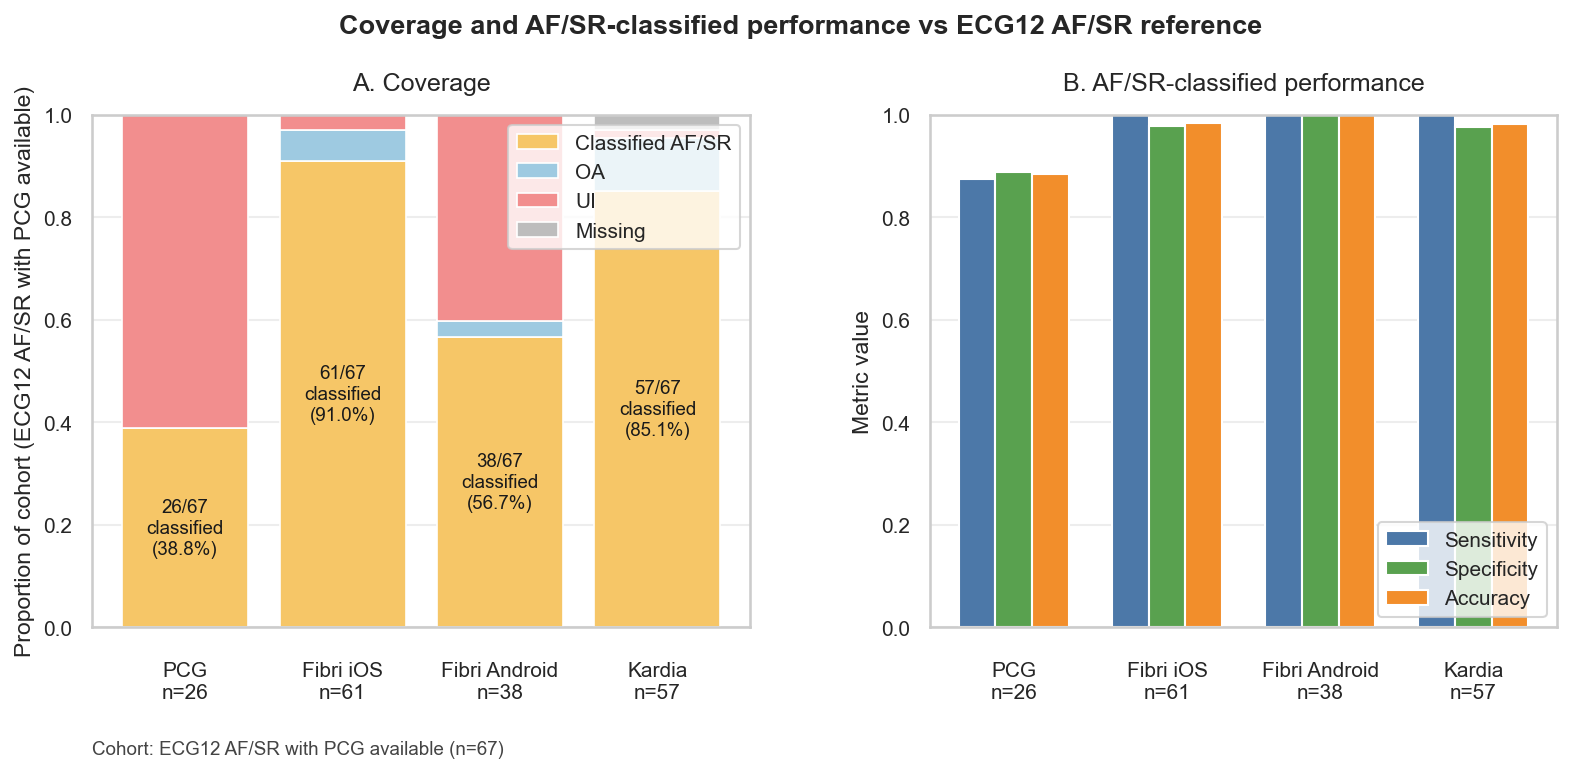

Saved Figure 2 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig2_coverage_performance.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig2_coverage_performance.pdf


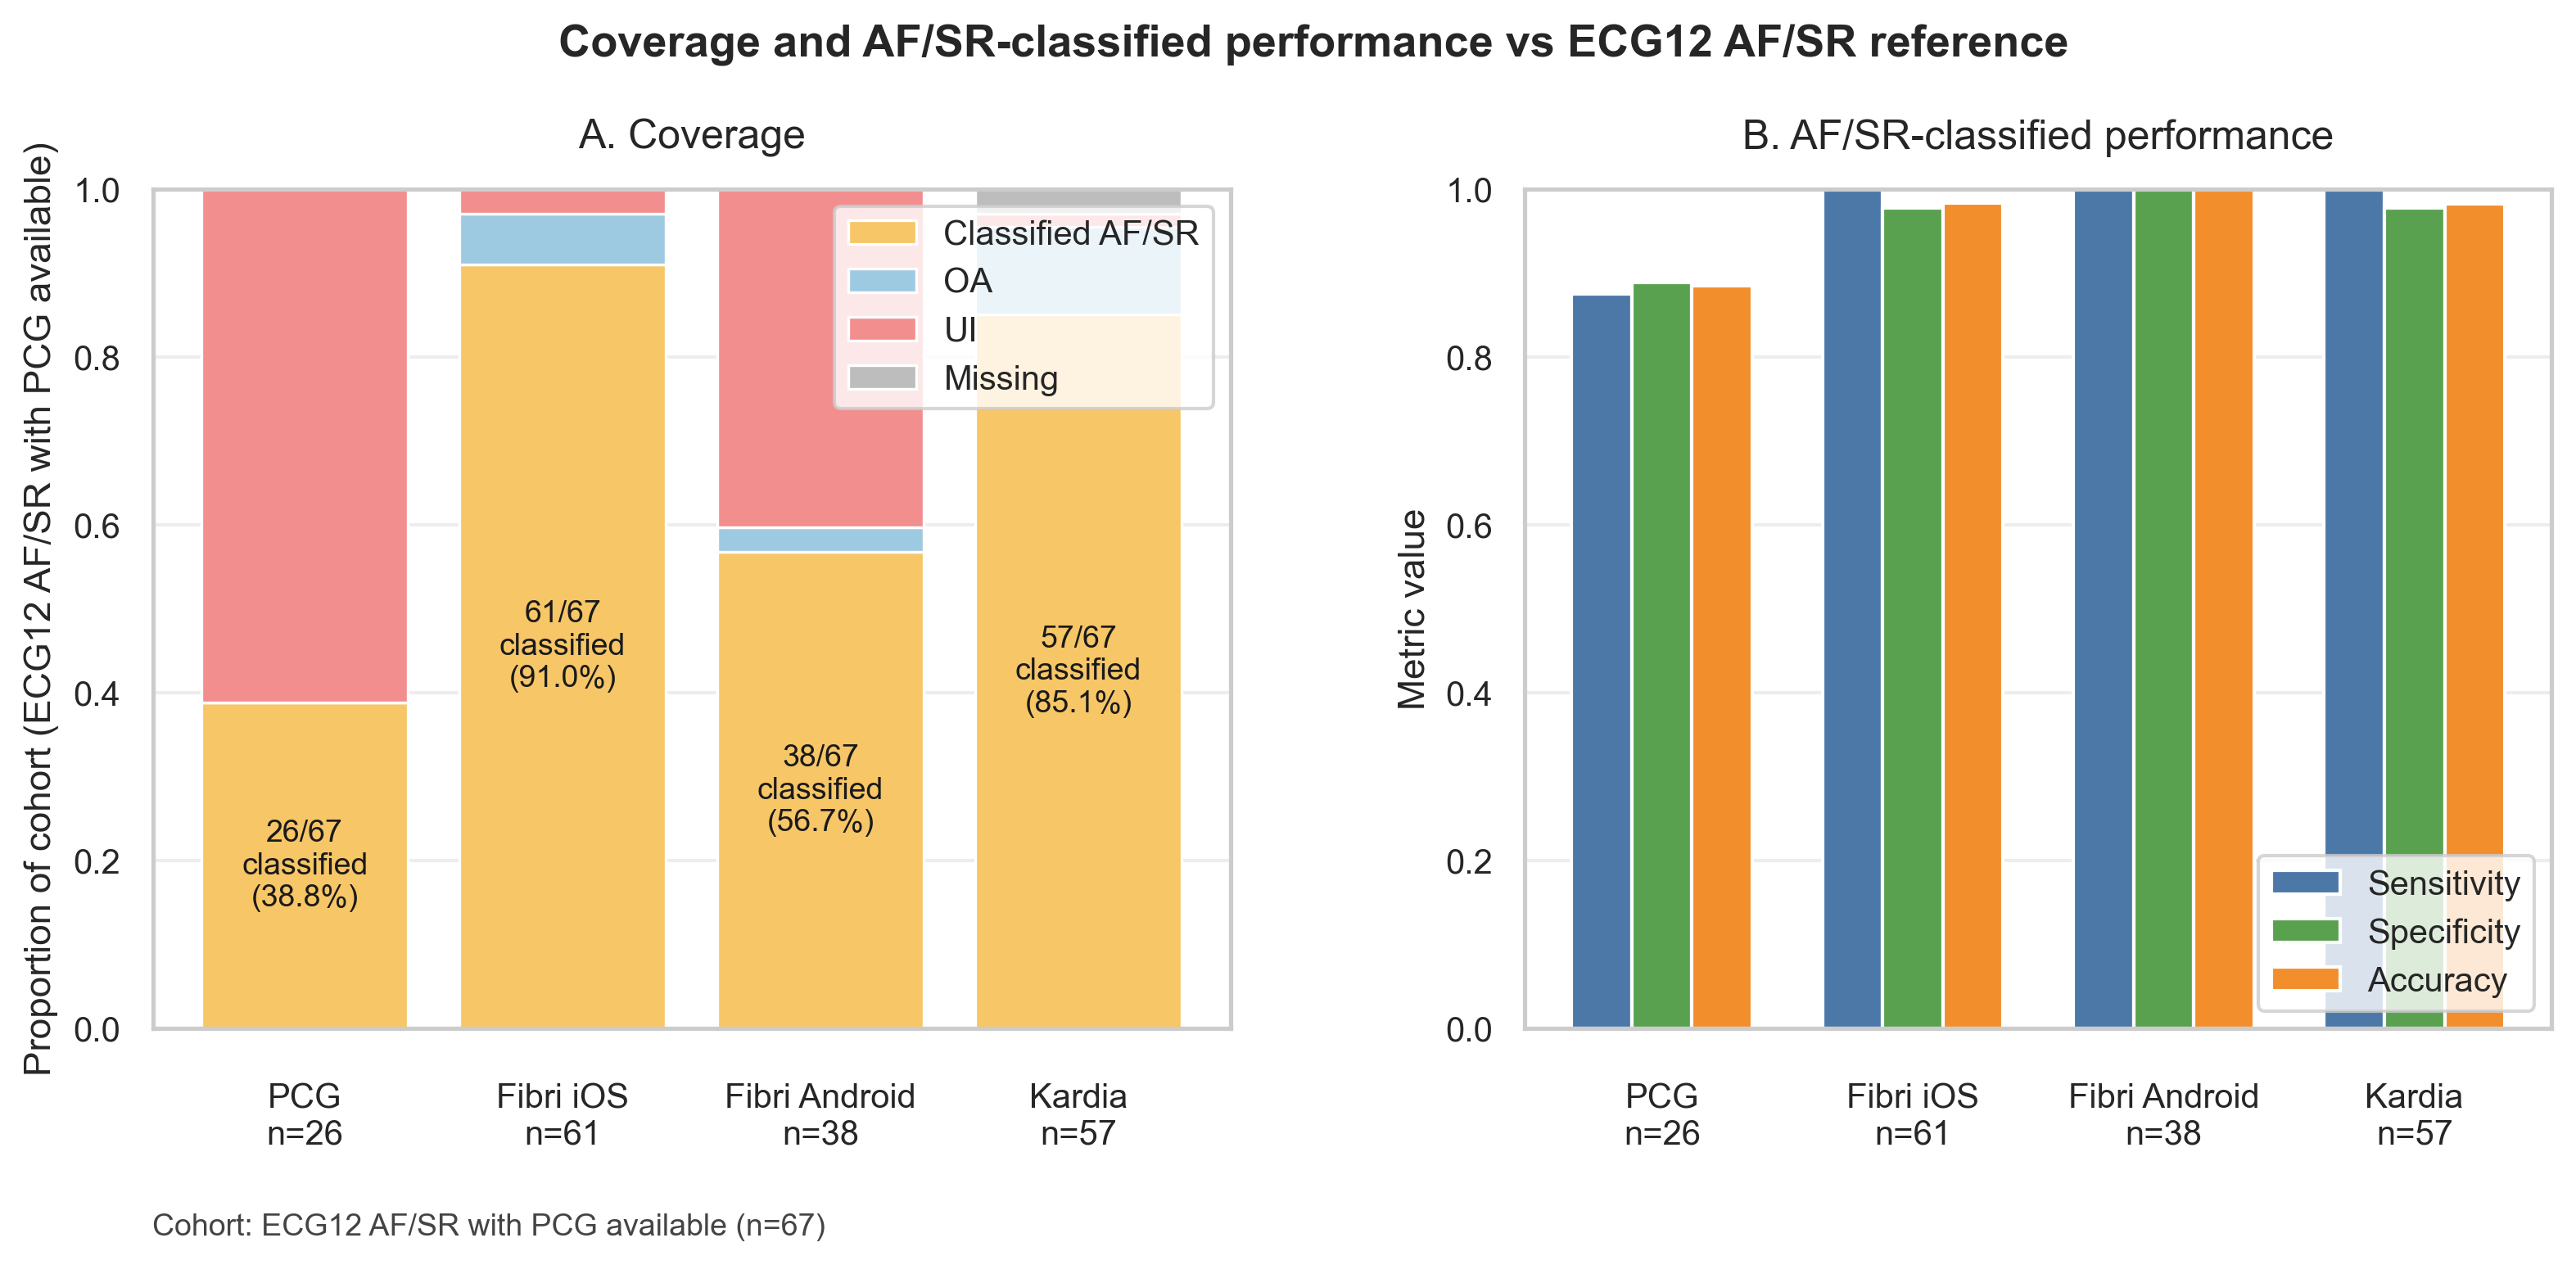

In [5]:
# Figure 2 (final-classified style): match dissertation layout.
import matplotlib as mpl

sns.set_theme(style='whitegrid')
mpl.rcParams.update(
    {
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'font.size': 11,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'axes.titlepad': 10,
    }
)

order = ['PCG', 'FibriCheck iOS', 'FibriCheck Android', 'Kardia']
methods = ['PCG', 'Fibri iOS', 'Fibri Android', 'Kardia']

# aligned rows
df2 = df_metrics.set_index('method').loc[order].reset_index()

n_ref = int(df2['n_ref'].iloc[0])
classified_n = df2['n_classified_AF_SR'].astype(int).to_numpy()
oa_n = df2['n_OA'].astype(int).to_numpy()
ui_n = df2['n_UI'].astype(int).to_numpy()
missing_n = df2['n_missing'].astype(int).to_numpy()

classified = classified_n / n_ref
oa = oa_n / n_ref
ui = ui_n / n_ref
missing = missing_n / n_ref

sens = df2['sensitivity'].astype(float).to_numpy()
spec = df2['specificity'].astype(float).to_numpy()
acc = df2['accuracy'].astype(float).to_numpy()

x = np.arange(len(methods))
xlabels = [f"{m}\nn={n}" for m, n in zip(methods, classified_n)]

fig = plt.figure(figsize=(12.6, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.0], wspace=0.28)

# Panel A: coverage
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x, classified, label='Classified AF/SR', color='#f6c667', edgecolor='white', linewidth=0.8)
ax1.bar(x, oa, bottom=classified, label='OA', color='#9ecae1', edgecolor='white', linewidth=0.8)
ax1.bar(x, ui, bottom=classified + oa, label='UI', color='#f28e8e', edgecolor='white', linewidth=0.8)
ax1.bar(x, missing, bottom=classified + oa + ui, label='Missing', color='#bdbdbd', edgecolor='white', linewidth=0.8)

ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, rotation=0, ha='center')
ax1.tick_params(axis='x', pad=10)
ax1.set_ylabel('Proportion of cohort (ECG12 AF/SR with PCG available)')
ax1.set_title('A. Coverage', pad=12)
ax1.grid(axis='x', visible=False)
ax1.grid(axis='y', alpha=0.35)
ax1.legend(loc='upper right', frameon=True)

for xi, n in enumerate(classified_n):
    pct = (n / n_ref) * 100.0
    y = max(0.04, classified[xi] / 2.0)
    ax1.text(
        xi,
        y,
        f"{n}/{n_ref}\nclassified\n({pct:.1f}%)",
        ha='center',
        va='center',
        fontsize=9,
        color='#1a1a1a',
    )

ax1.text(
    0.0,
    -0.22,
    f'Cohort: ECG12 AF/SR with PCG available (n={n_ref})',
    transform=ax1.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    color='#444444',
)

# Panel B: AF/SR-classified performance
ax2 = fig.add_subplot(gs[0, 1])
width = 0.24
ax2.bar(x - width, sens, width, label='Sensitivity', color='#4c78a8')
ax2.bar(x, spec, width, label='Specificity', color='#59a14f')
ax2.bar(x + width, acc, width, label='Accuracy', color='#f28e2b')
ax2.set_ylim(0, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels(xlabels, rotation=0, ha='center')
ax2.tick_params(axis='x', pad=10)
ax2.set_ylabel('Metric value')
ax2.set_title('B. AF/SR-classified performance', pad=12)
ax2.grid(axis='x', visible=False)
ax2.grid(axis='y', alpha=0.35)
ax2.legend(loc='lower right', frameon=True)

fig.suptitle('Coverage and AF/SR-classified performance vs ECG12 AF/SR reference', y=0.98, fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.86, bottom=0.25)

plt.show()

saved = save_figure_outputs(
    fig,
    repo_base_name='fig2_coverage_performance',
    run_base_name='fig2_coverage_performance_notebook',
    kind='main',
    save_repo=bool(SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY),
    save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
    dpi=int(FIGURE_DPI),
)
if saved:
    print('Saved Figure 2 outputs:')
    for path in saved:
        print('-', path)


if SHOW_SAVED_REPO_FIGURES and (SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY):
    from IPython.display import Image, display
    p = REPO_MAIN_FIG_DIR / 'fig2_coverage_performance.png'
    if p.exists():
        display(Image(filename=str(p)))

plt.close(fig)






## Figure 3: PCG confusion matrix and ROC (protected-local when available)


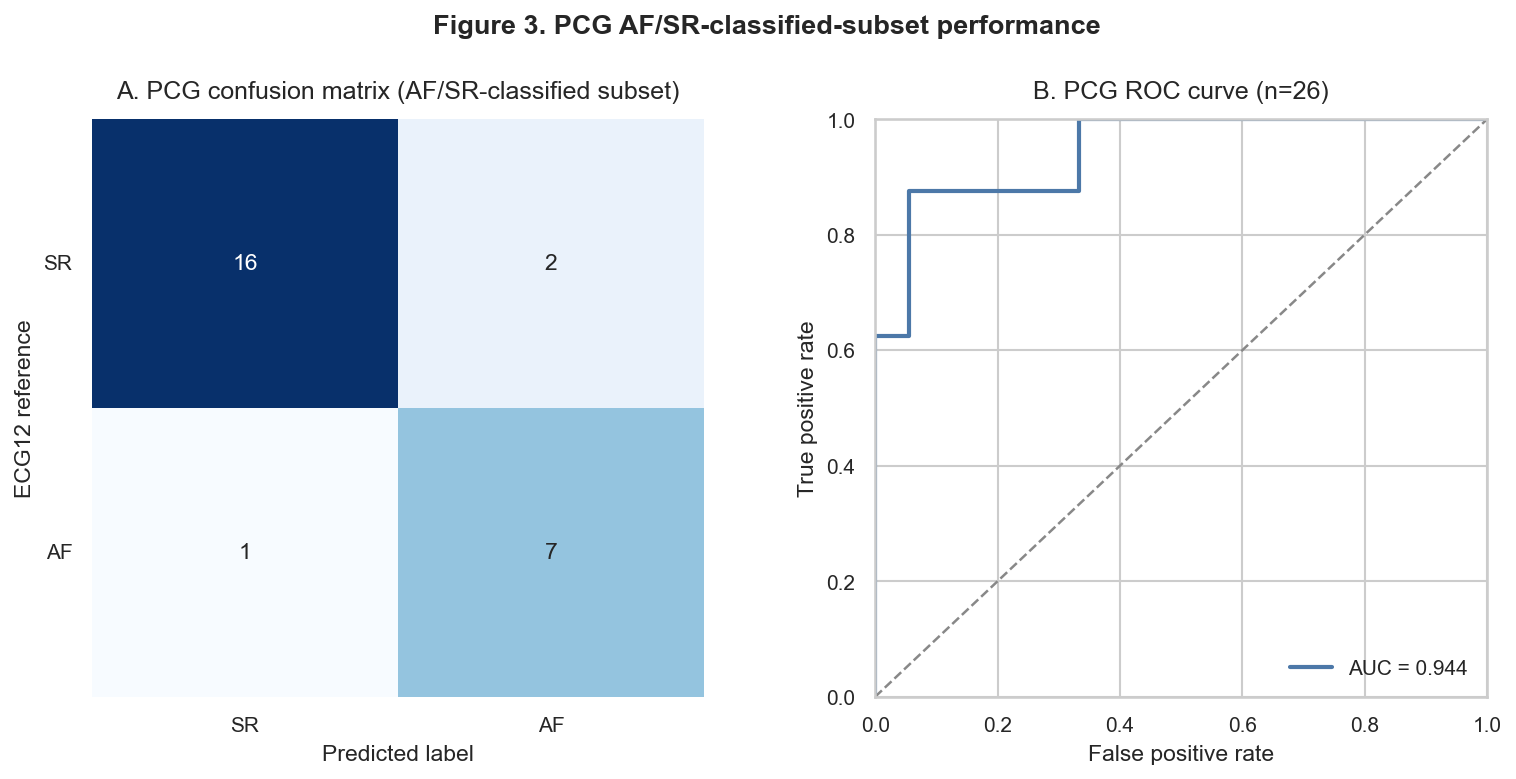

Saved Figure 3 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig3_pcg_performance.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/main/fig3_pcg_performance.pdf


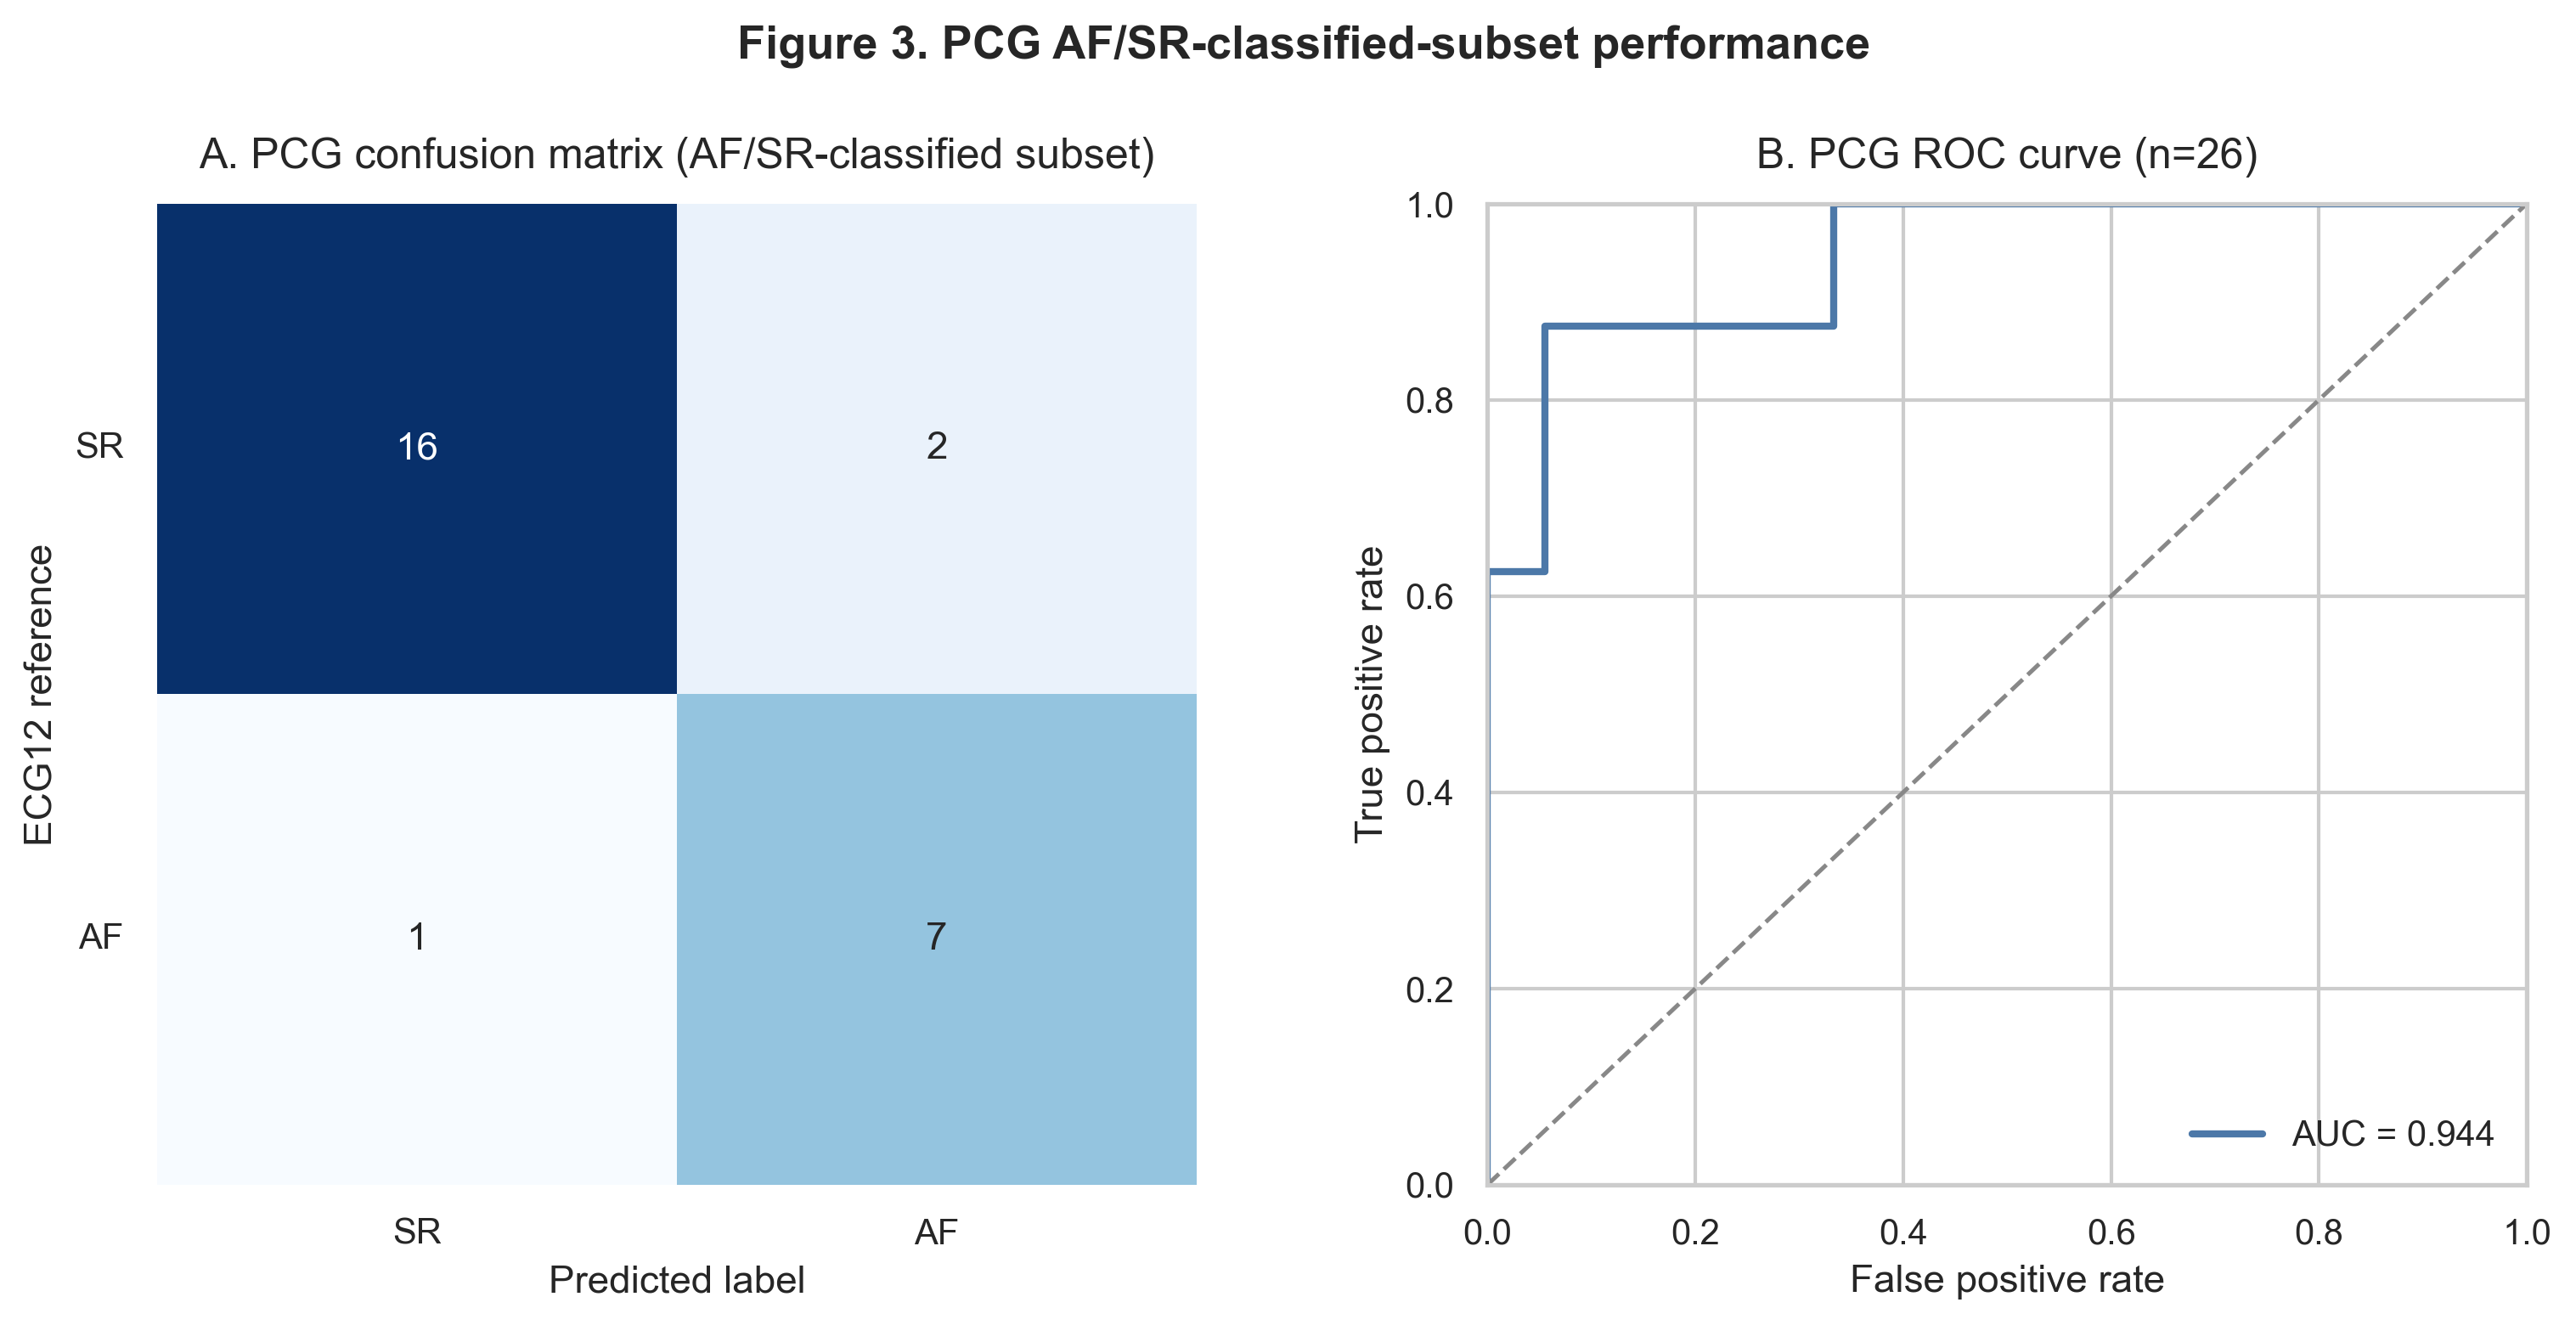

In [6]:
# Build confusion matrix and ROC source from local/public tables.
roc_df = None
roc_source = None

if PROTECTED_MATCHED_TABLE is not None and PROTECTED_MATCHED_TABLE.exists():
    cand = pd.read_csv(PROTECTED_MATCHED_TABLE)
    if 'ecg12_4class' in cand.columns:
        roc_df = cand
        roc_source = str(PROTECTED_MATCHED_TABLE)

if roc_df is None and PROTECTED_PCG_PREDICTIONS_CSV is not None and PROTECTED_PCG_PREDICTIONS_CSV.exists():
    pred = pd.read_csv(PROTECTED_PCG_PREDICTIONS_CSV)
    if PROTECTED_LABELS_CSV is not None and PROTECTED_LABELS_CSV.exists() and 'participant_id' in pred.columns:
        lab = pd.read_csv(PROTECTED_LABELS_CSV, usecols=['participant_id', 'ecg12_4class'])
        lab['participant_id'] = lab['participant_id'].astype(str)
        pred['participant_id'] = pred['participant_id'].astype(str)
        roc_df = pred.merge(lab, on='participant_id', how='left')
        roc_source = f"{PROTECTED_PCG_PREDICTIONS_CSV} + {PROTECTED_LABELS_CSV}"

prob_col = None
pred_col = None
if roc_df is not None:
    if 'pcg_paf' in roc_df.columns:
        prob_col = 'pcg_paf'
    elif 'pcg_paf_oof' in roc_df.columns:
        prob_col = 'pcg_paf_oof'
    elif 'pcg_paf_full' in roc_df.columns:
        prob_col = 'pcg_paf_full'

    pred_candidates = ['pcg_pred_4class', 'pcg_pred_4class_oof', 'pcg_pred_oof', 'pcg_pred_full']
    pred_col = next((c for c in pred_candidates if c in roc_df.columns), None)


def confusion_from_pred_table(df: pd.DataFrame, pred_column: str) -> np.ndarray | None:
    sub = df.copy()
    sub = sub[sub['ecg12_4class'].isin(['AF', 'SR'])]
    sub = sub[sub[pred_column].isin(['AF', 'SR'])]
    if sub.empty:
        return None

    ref_af = sub['ecg12_4class'].astype(str).str.upper() == 'AF'
    pred_af = sub[pred_column].astype(str).str.upper() == 'AF'

    tp = int((ref_af & pred_af).sum())
    tn = int((~ref_af & ~pred_af).sum())
    fp = int((~ref_af & pred_af).sum())
    fn = int((ref_af & ~pred_af).sum())
    return np.asarray([[tn, fp], [fn, tp]], dtype=int)


def infer_confusion_from_rates(row: pd.Series) -> np.ndarray | None:
    n = int(row.get('n_classified_AF_SR', 0) or 0)
    if n <= 1:
        return None

    metric_names = ['sensitivity', 'specificity', 'accuracy', 'PPV', 'NPV', 'F1']
    targets = {}
    for name in metric_names:
        if name in row.index and pd.notna(row[name]):
            targets[name] = float(row[name])

    if not targets:
        return None

    def _safe_div(num: float, den: float) -> float:
        return float(num / den) if den > 0 else float('nan')

    best = None
    best_score = float('inf')

    for n_pos in range(1, n):
        n_neg = n - n_pos
        for tp in range(0, n_pos + 1):
            fn = n_pos - tp
            for tn in range(0, n_neg + 1):
                fp = n_neg - tn

                vals = {
                    'sensitivity': _safe_div(tp, tp + fn),
                    'specificity': _safe_div(tn, tn + fp),
                    'accuracy': _safe_div(tp + tn, n),
                    'PPV': _safe_div(tp, tp + fp),
                    'NPV': _safe_div(tn, tn + fn),
                    'F1': _safe_div(2 * tp, 2 * tp + fp + fn),
                }

                score = 0.0
                for k, target in targets.items():
                    score += (vals[k] - target) ** 2

                if score < best_score:
                    best_score = score
                    best = (tn, fp, fn, tp)

    if best is None:
        return None

    tn, fp, fn, tp = best
    if best_score > 0.02:
        return None

    print('Confusion matrix inferred from rounded aggregate metrics (no raw tp/fp/tn/fn available).')
    return np.asarray([[tn, fp], [fn, tp]], dtype=int)


cm = None
pcg_row = df_metrics[df_metrics['method'] == 'PCG'].iloc[0]

try:
    cm = confusion_matrix_from_metrics_row(pcg_row)
except ValueError:
    pass

if cm is None:
    summary_pcg = None
    if PROTECTED_RUN_DIR is not None:
        candidate = Path(PROTECTED_RUN_DIR) / 'evaluation' / 'summary_PCG.json'
        if candidate.exists():
            summary_pcg = json.loads(candidate.read_text(encoding='utf-8'))
    if isinstance(summary_pcg, dict):
        metrics = summary_pcg.get('metrics') or {}
        needed = ['tp', 'fp', 'tn', 'fn']
        if all(k in metrics for k in needed):
            tp = int(metrics['tp'])
            fp = int(metrics['fp'])
            tn = int(metrics['tn'])
            fn = int(metrics['fn'])
            cm = np.asarray([[tn, fp], [fn, tp]], dtype=int)

if cm is None and roc_df is not None and pred_col is not None and 'ecg12_4class' in roc_df.columns:
    cm = confusion_from_pred_table(roc_df, pred_col)

if cm is None:
    cm = infer_confusion_from_rates(pcg_row)

roc_ready = False
fpr = tpr = None
auc = float('nan')
n_roc = 0
if roc_df is not None and prob_col is not None and 'ecg12_4class' in roc_df.columns:
    sub = roc_df.copy()
    sub = sub[sub['ecg12_4class'].isin(['AF', 'SR'])]
    if pred_col is not None:
        sub = sub[sub[pred_col].isin(['AF', 'SR'])]
    p = pd.to_numeric(sub[prob_col], errors='coerce')
    sub = sub[np.isfinite(p.to_numpy())].copy()

    if len(sub) >= 3 and len(set(sub['ecg12_4class'].tolist())) == 2:
        y_true = (sub['ecg12_4class'].astype(str).str.upper() == 'AF').astype(int).to_numpy()
        y_score = pd.to_numeric(sub[prob_col], errors='coerce').to_numpy(dtype=float)
        fpr, tpr, _thr, auc = compute_roc_curve(y_true, y_score)
        n_roc = len(sub)
        roc_ready = True

# Plot Figure 3 (confusion + ROC when available).
if cm is not None and roc_ready:
    fig = plt.figure(figsize=(12.0, 5.0))
    gs = fig.add_gridspec(1, 2, wspace=0.28)

    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.0, ax=ax1)
    ax1.set_xlabel('Predicted label')
    ax1.set_ylabel('ECG12 reference')
    ax1.set_xticklabels(['SR', 'AF'])
    ax1.set_yticklabels(['SR', 'AF'], rotation=0)
    ax1.set_title('A. PCG confusion matrix (AF/SR-classified subset)')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(fpr, tpr, lw=2.0, color='#4c78a8', label=f'AUC = {auc:.3f}')
    ax2.plot([0, 1], [0, 1], ls='--', lw=1.2, color='#888888')
    ax2.set_xlabel('False positive rate')
    ax2.set_ylabel('True positive rate')
    ax2.set_title(f'B. PCG ROC curve (n={n_roc})')
    ax2.legend(loc='lower right', frameon=False)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

    fig.suptitle('Figure 3. PCG AF/SR-classified-subset performance', y=1.02, fontsize=13, fontweight='bold')
elif cm is not None:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.0, ax=ax)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('ECG12 reference')
    ax.set_xticklabels(['SR', 'AF'])
    ax.set_yticklabels(['SR', 'AF'], rotation=0)
    ax.set_title('PCG confusion matrix (AF/SR-classified subset)')

else:
    fig, ax = plt.subplots(figsize=(6.2, 3.8))
    ax.axis('off')
    ax.text(
        0.5,
        0.55,
        'Confusion matrix unavailable',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
    )
    ax.text(
        0.5,
        0.37,
        'Need one of:\n- tp/fp/tn/fn columns\n- local evaluation/summary_PCG.json\n- local AF/SR predictions + labels',
        ha='center',
        va='center',
        fontsize=10,
    )

plt.show()

saved = save_figure_outputs(
    fig,
    repo_base_name='fig3_pcg_performance',
    run_base_name='fig3_pcg_confusion_roc_notebook',
    kind='main',
    save_repo=bool(SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY),
    save_run=bool(EXPORT_FIGURES_TO_RUN_DIR),
    dpi=int(FIGURE_DPI),
)
if saved:
    print('Saved Figure 3 outputs:')
    for path in saved:
        print('-', path)


if SHOW_SAVED_REPO_FIGURES and (SAVE_REGENERATED_FIGURES or EXPORT_FIGURES_TO_REPOSITORY):
    from IPython.display import Image, display
    p = REPO_MAIN_FIG_DIR / 'fig3_pcg_performance.png'
    if p.exists():
        display(Image(filename=str(p)))

plt.close(fig)









## Methodology figures


/Users/soonheekim/Desktop/FYP/github_push/Code_v01/src/methodology_figures.py:102: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, samples = wavfile.read(str(path))


Saved M1 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM1_preprocessing_example.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM1_preprocessing_example.pdf
Saved M2 outputs:
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM2_s1s2_annotation_rr_example.png
- /Users/soonheekim/Desktop/FYP/github_push/Code_v01/figures/methodology/figM2_s1s2_annotation_rr_example.pdf


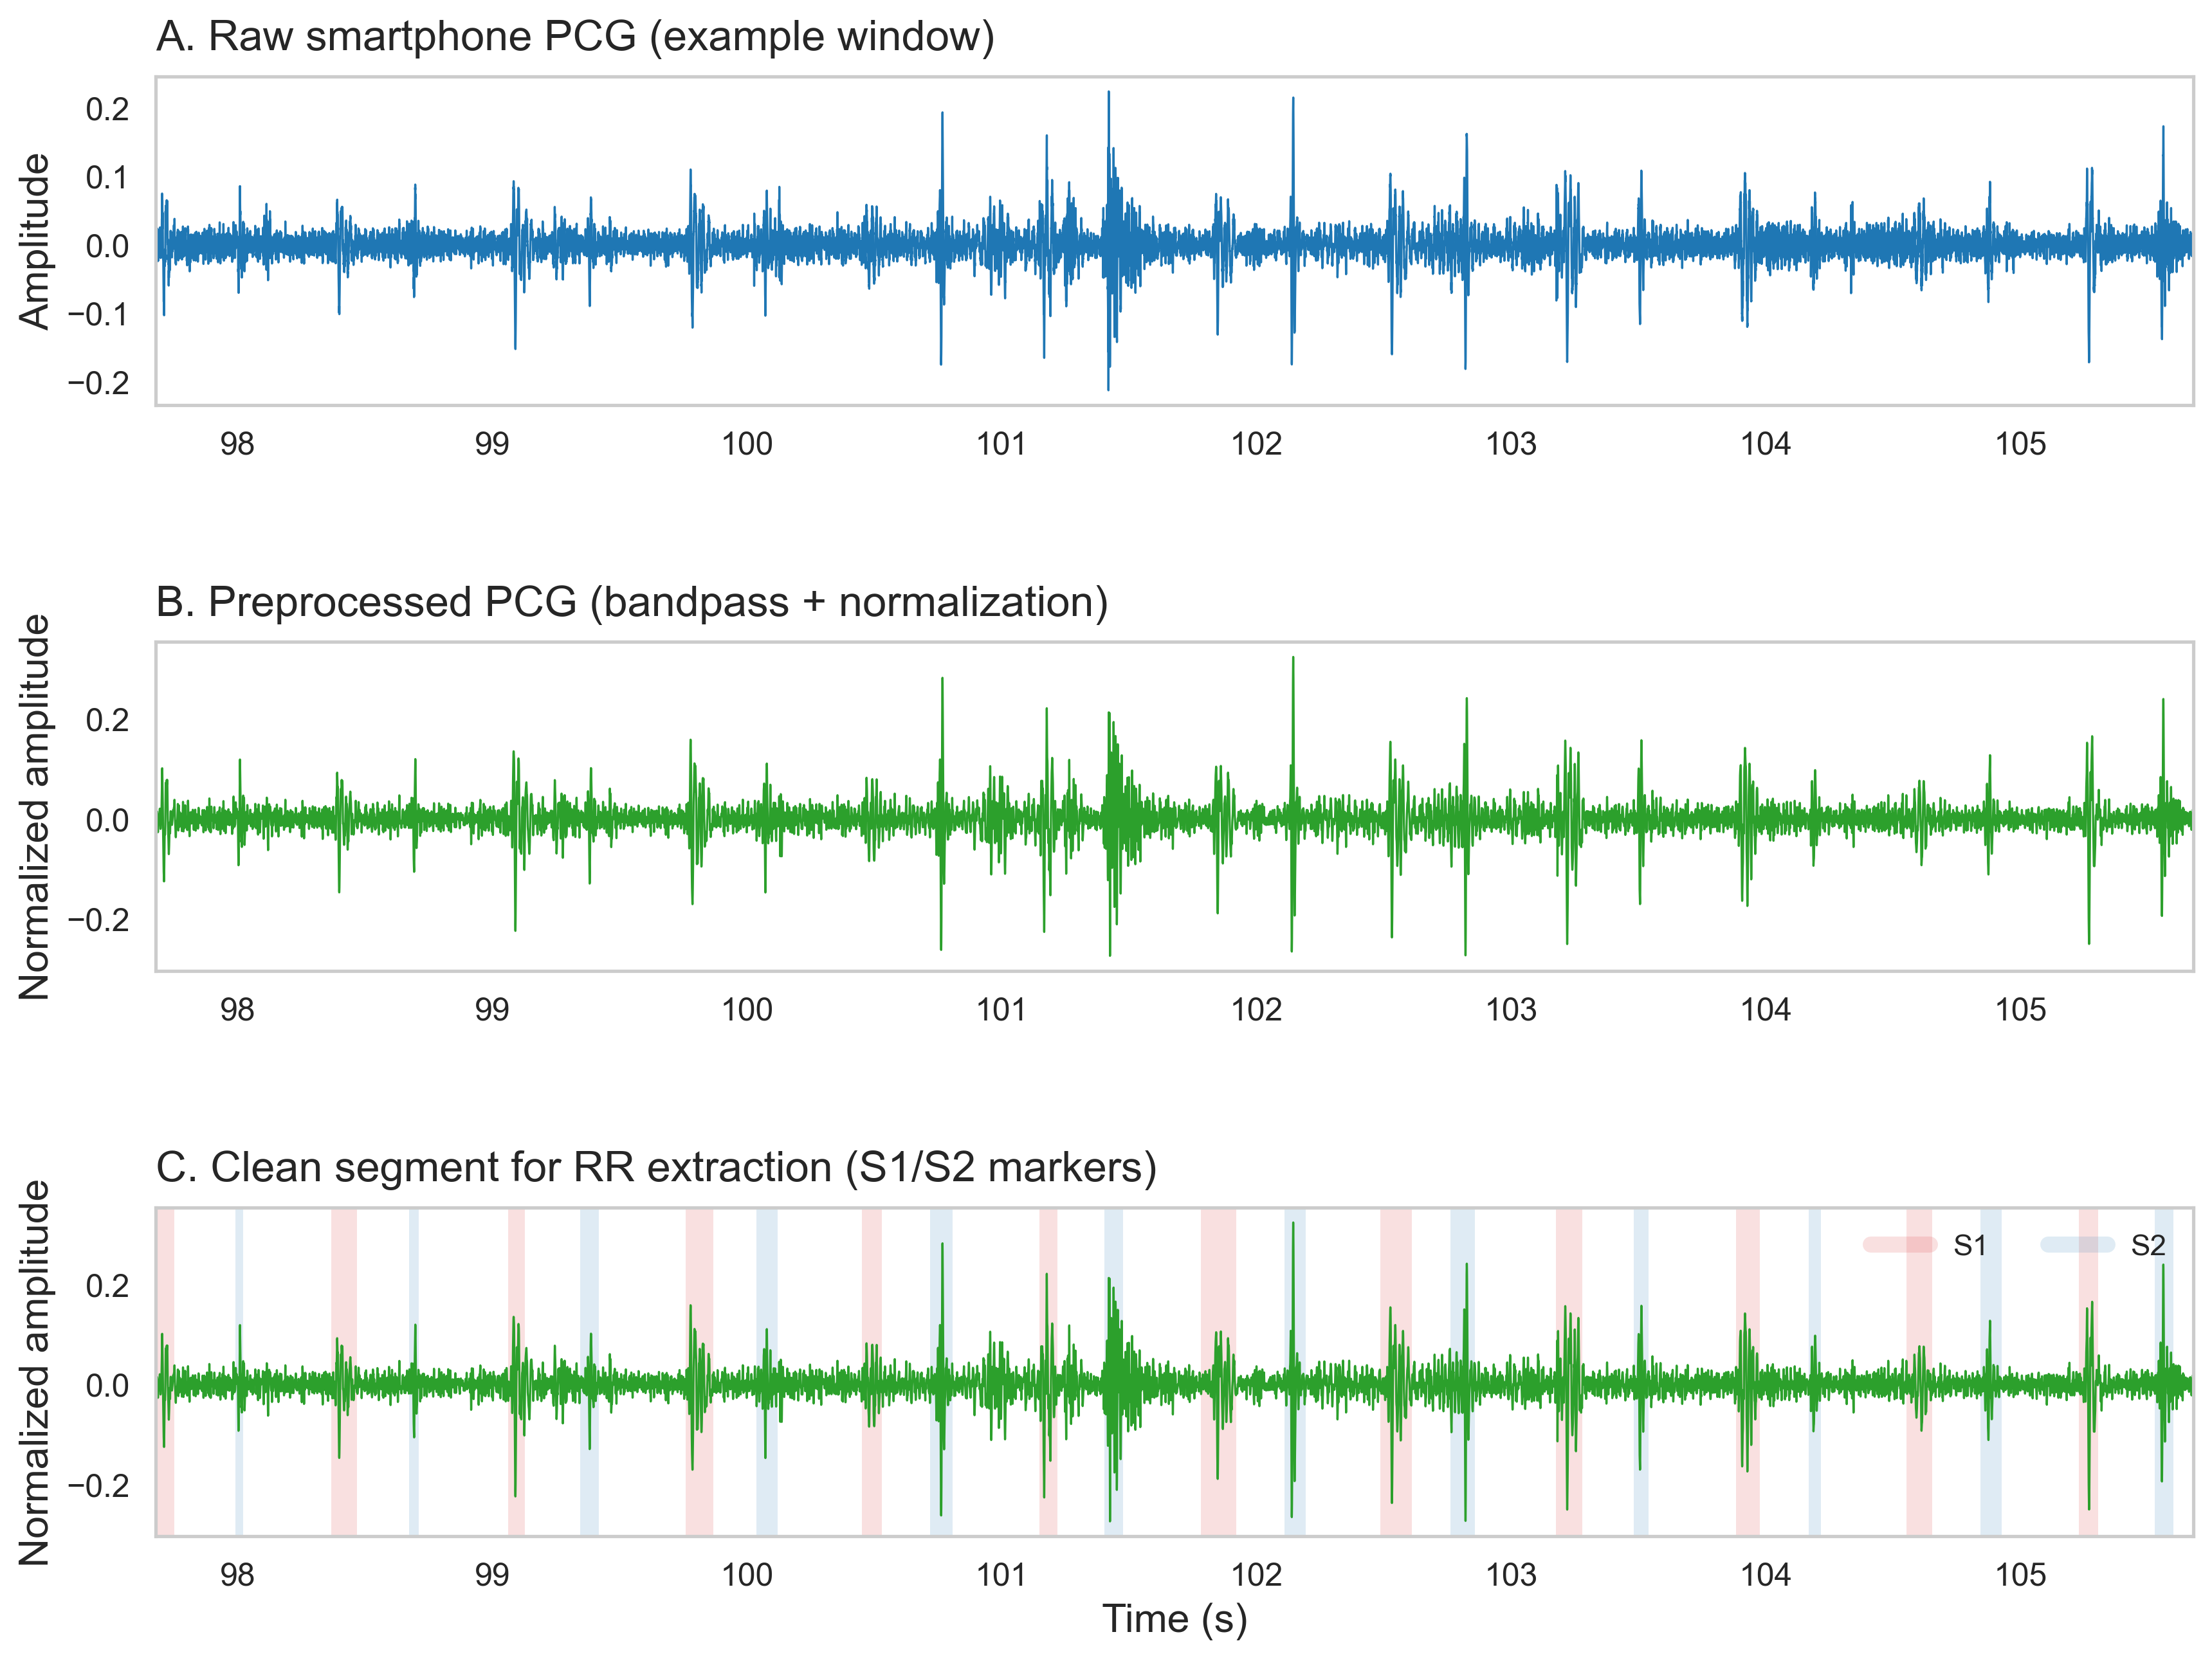

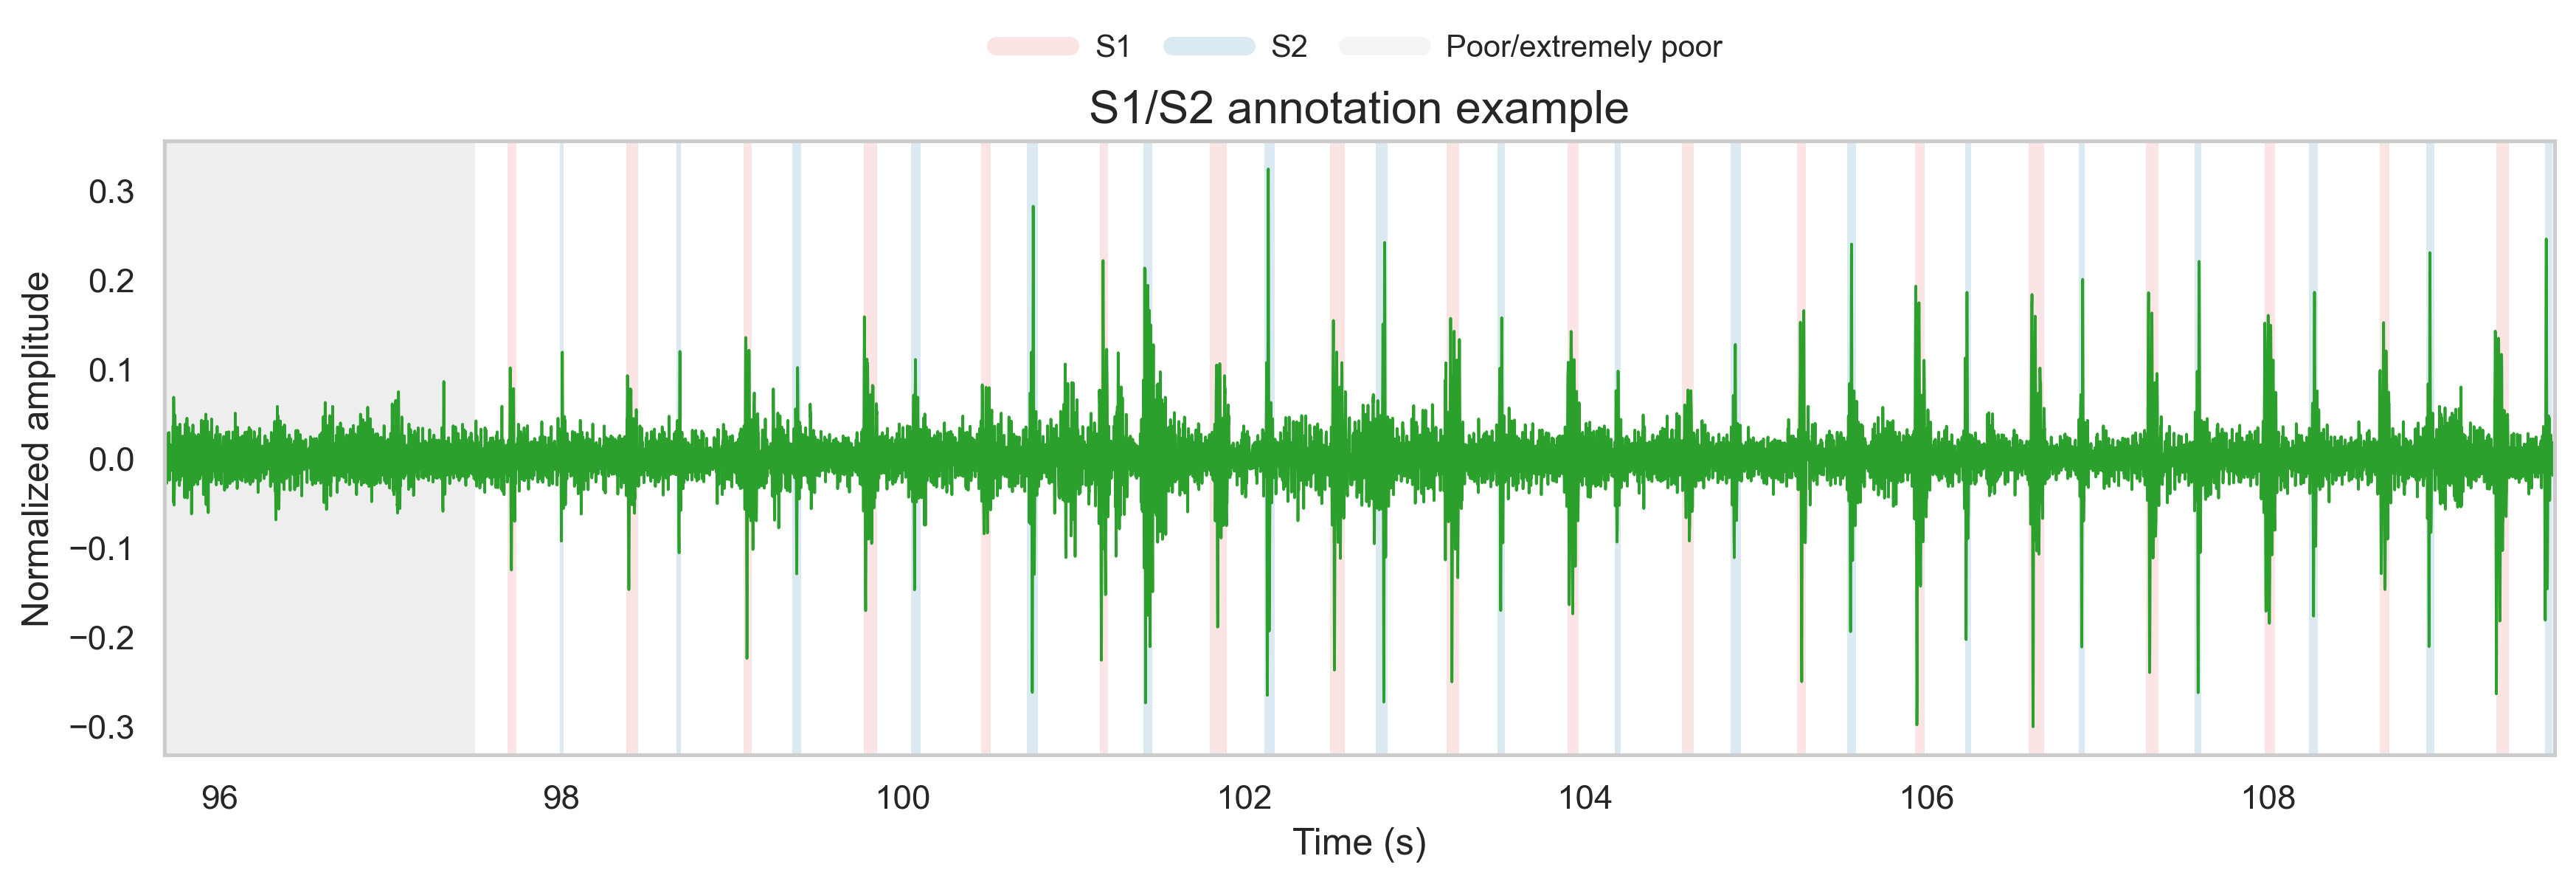

In [7]:
# Optional protected-local methodology figures.
# This block is skipped unless required local paths are set.

from IPython.display import Image, display

from src.methodology_figures import (
    load_annotation_payload_for_participant,
    plot_preprocessing_example,
    plot_s1s2_annotation_example,
    load_wav
)

required = {
    'PROTECTED_RAW_AUDIO_PATH': PROTECTED_RAW_AUDIO_PATH,
    'PROTECTED_PREPROCESSED_AUDIO_PATH': PROTECTED_PREPROCESSED_AUDIO_PATH,
    'PROTECTED_ANNOTATION_CSV': PROTECTED_ANNOTATION_CSV,
    'PROTECTED_ANNOTATION_KEY_CSV': PROTECTED_ANNOTATION_KEY_CSV,
    'METHODOLOGY_EXAMPLE_PARTICIPANT': METHODOLOGY_EXAMPLE_PARTICIPANT,
    'METHODOLOGY_TIME_WINDOW': METHODOLOGY_TIME_WINDOW,
}

missing = []
for key in ['PROTECTED_RAW_AUDIO_PATH', 'PROTECTED_PREPROCESSED_AUDIO_PATH', 'PROTECTED_ANNOTATION_CSV', 'PROTECTED_ANNOTATION_KEY_CSV']:
    value = required.get(key)
    if value in (None, ''):
        missing.append(key)
    elif not Path(value).expanduser().exists():
        missing.append(f'{key} (not found)')

if required['METHODOLOGY_EXAMPLE_PARTICIPANT'] in (None, ''):
    missing.append('METHODOLOGY_EXAMPLE_PARTICIPANT')

window = required['METHODOLOGY_TIME_WINDOW']
if not isinstance(window, tuple) or len(window) != 2:
    missing.append('METHODOLOGY_TIME_WINDOW')
else:
    try:
        float(window[0])
        float(window[1])
    except Exception:
        missing.append('METHODOLOGY_TIME_WINDOW')

methodology_ok = len(missing) == 0

if methodology_ok:
    show_saved_only = bool(SHOW_SAVED_REPO_FIGURES and EXPORT_METHODOLOGY_FIGURES)
    start_s, duration_s = METHODOLOGY_TIME_WINDOW
    recording_filename = Path(PROTECTED_PREPROCESSED_AUDIO_PATH).name

    payload = load_annotation_payload_for_participant(
        PROTECTED_ANNOTATION_CSV,
        PROTECTED_ANNOTATION_KEY_CSV,
        participant_id=METHODOLOGY_EXAMPLE_PARTICIPANT,
        filename=recording_filename,
    )

    fig_m1 = plot_preprocessing_example(
        raw_wav=PROTECTED_RAW_AUDIO_PATH,
        preprocessed_wav=PROTECTED_PREPROCESSED_AUDIO_PATH,
        start_s=float(start_s),
        duration_s=float(duration_s),
        payload=payload,
    )
    if not show_saved_only:
        plt.figure(fig_m1.number)
        plt.show()

    if EXPORT_METHODOLOGY_FIGURES:
        saved_m1 = save_figure_outputs(
            fig_m1,
            repo_base_name='figM1_preprocessing_example',
            run_base_name=None,
            kind='methodology',
            save_repo=True,
            save_run=False,
            dpi=int(FIGURE_DPI),
        )
        if saved_m1:
            print('Saved M1 outputs:')
            for path in saved_m1:
                print('-', path)
    plt.close(fig_m1)

    # M2 uses a wider context window (match dissertation-style layout).
    w_pre_full = load_wav(PROTECTED_PREPROCESSED_AUDIO_PATH)
    total_duration_s = float(w_pre_full.samples.size) / float(w_pre_full.fs)
    m2_start_s = max(0.0, float(start_s) - 2.0)
    m2_end_s = min(float(total_duration_s), float(start_s) + 12.0)
    m2_duration_s = max(0.5, float(m2_end_s - m2_start_s))

    fig_m2 = plot_s1s2_annotation_example(
        preprocessed_wav=PROTECTED_PREPROCESSED_AUDIO_PATH,
        payload=payload,
        start_s=float(m2_start_s),
        duration_s=float(m2_duration_s),
    )
    if not show_saved_only:
        plt.figure(fig_m2.number)
        plt.show()

    if EXPORT_METHODOLOGY_FIGURES:
        saved_m2 = save_figure_outputs(
            fig_m2,
            repo_base_name='figM2_s1s2_annotation_rr_example',
            run_base_name=None,
            kind='methodology',
            save_repo=True,
            save_run=False,
            dpi=int(FIGURE_DPI),
        )
        if saved_m2:
            print('Saved M2 outputs:')
            for path in saved_m2:
                print('-', path)
    if show_saved_only:
        p1 = REPO_METHODOLOGY_FIG_DIR / 'figM1_preprocessing_example.png'
        p2 = REPO_METHODOLOGY_FIG_DIR / 'figM2_s1s2_annotation_rr_example.png'
        if p1.exists():
            display(Image(filename=str(p1)))
        if p2.exists():
            display(Image(filename=str(p2)))

    plt.close(fig_m2)

else:
    print('Protected methodology inputs not configured; skipping methodology plots.')








